In [1]:
import pandas as pd

# 1️⃣ Load CSV (skip header lines starting with '#')
df = pd.read_csv(
    "Data/CAMS_15min_20240101_20250401_EHV.csv",
    comment="#",
    sep=";"
)

# 2️⃣ Rename columns for clarity
df.columns = [
    "observation_period", "TOA", "ClearSkyGHI", "ClearSkyBHI", "ClearSkyDHI", "ClearSkyBNI",
    "GHI", "BHI", "DHI", "BNI", "Reliability"
]

# 3️⃣ Extract start time from Observation period (before '/')
df["time_utc"] = df["observation_period"].str.split("/").str[0]
df["time_utc"] = pd.to_datetime(df["time_utc"], utc=True)

# 4️⃣ Convert UTC to local time (Europe/Amsterdam)
df["time_local"] = df["time_utc"].dt.tz_convert("Europe/Amsterdam")

# 5️⃣ Drop unnecessary columns
df = df[["time_local", "GHI", "DNI", "DHI"]] if "DNI" in df.columns else df[["time_local", "GHI", "BHI", "DHI"]]

# 6️⃣ Sort and reset index
df = df.sort_values("time_local").reset_index(drop=True)

print(df.head(10))


                 time_local  GHI  BHI  DHI
0 2024-01-01 01:15:00+01:00  0.0  0.0  0.0
1 2024-01-01 01:30:00+01:00  0.0  0.0  0.0
2 2024-01-01 01:45:00+01:00  0.0  0.0  0.0
3 2024-01-01 02:00:00+01:00  0.0  0.0  0.0
4 2024-01-01 02:15:00+01:00  0.0  0.0  0.0
5 2024-01-01 02:30:00+01:00  0.0  0.0  0.0
6 2024-01-01 02:45:00+01:00  0.0  0.0  0.0
7 2024-01-01 03:00:00+01:00  0.0  0.0  0.0
8 2024-01-01 03:15:00+01:00  0.0  0.0  0.0
9 2024-01-01 03:30:00+01:00  0.0  0.0  0.0


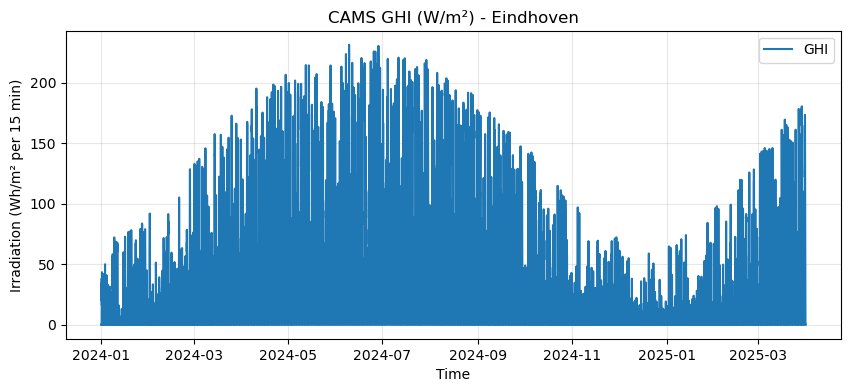

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df["time_local"], df["GHI"], label="GHI")
plt.title("CAMS GHI (W/m²) - Eindhoven")
plt.xlabel("Time")
plt.ylabel("Irradiation (Wh/m² per 15 min)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [3]:
df["GHI_Wm2"] = df["GHI"] / (900 / 3600)  # or df["GHI"] / 0.25

In [4]:
df.to_csv("data/CAMS_clean_EHV.csv", index=False)

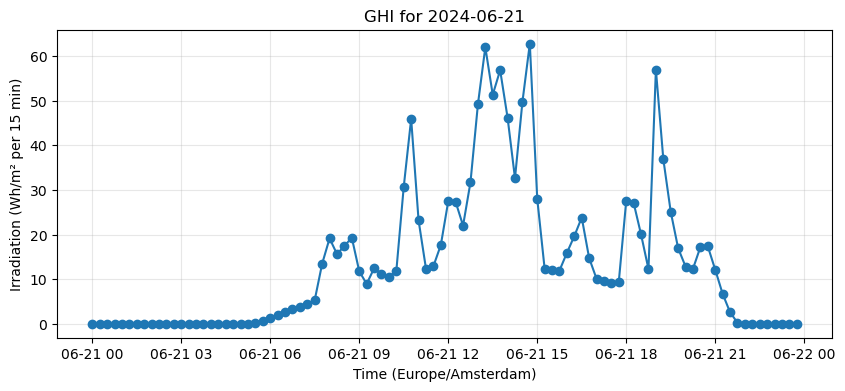

In [5]:
import matplotlib.pyplot as plt

day = "2024-06-21"  # pick midsummer
mask = df["time_local"].dt.date == pd.to_datetime(day).date()

plt.figure(figsize=(10,4))
plt.plot(df.loc[mask, "time_local"], df.loc[mask, "GHI"], marker='o')
plt.title(f"GHI for {day}")
plt.xlabel("Time (Europe/Amsterdam)")
plt.ylabel("Irradiation (Wh/m² per 15 min)")
plt.grid(True, alpha=0.3)
plt.show()


In [6]:
df_day = df[df["GHI"] > 0]
daily_mean = df_day.resample("D", on="time_local")["GHI"].mean()
